<a href="https://colab.research.google.com/github/cesartejido/TFM_Producto_Diabetes/blob/main/TFM_Producto_IA_Diabetes.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **TFM - Clasificación de pacientes diabéticos (Pima Indians Diabetes Dataset)**

## Autor: Julio César Tejido González
## Director: Cristian Rodríguez


# ***Bloque 1: Carga, EDA y preprocesamiento***

In [1]:
# El primero paso, es  preparar el entorno cargando las librerias que se utilizarán más adelante.

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer, KNNImputer
from sklearn.preprocessing import StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from scipy import stats

sns.set_theme(style="whitegrid")
RANDOM_STATE = 42  # Fijación de la semilla de aleatoriedad (RANDOM_STATE) para garantizar la reproducibilidad de los resultados.

 ## **1. Carga de datos**

In [2]:
# El segundo paso, imprescindible antes de ejecutar las siguientes linea de coódigo, es cargar el dataset "diabetes.csv" en los archivos de Colab.

df = pd.read_csv("diabetes.csv") # Leemos el archivo que subido al entorno y lo convertimos en un DataFrame.

print(f"Dimensiones del dataset: {df.shape}")
df.head()
# Se ven en las primeras cinco filas del dataset.
# En las columnas SkinThickness y Insulin podemos ver el valoros 0, esos ceros son exactamente los datos faltantes enmascarados que se deben tratar.

Dimensiones del dataset: (768, 9)


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


Ocho variables predictoras:
* Pregnancies (Número de embarazos): variable numérica entera de tipo discreto, expresada como un simple recuento sin unidad de medida. Un número elevado de embarazos se asocia a mayor riesgo de diabetes gestacional previa.
* Glucose (Glucosa plasmática): variable numérica entera de naturaleza continua, medida en miligramos por decilitro (mg/dL) a las dos horas de un test de tolerancia oral a la glucosa. En una persona sana el valor se mantiene por debajo de 140, mientras que entre 140 y 199 se considera prediabetes y a partir de 200 se cumple el criterio diagnóstico de diabetes.
* BloodPressure (Presión arterial diastólica): variable numérica entera de tipo continuo, expresada en milímetros de mercurio (mm Hg). Se considera normal por debajo de 80, y a partir de 90 ya se habla de hipertensión.
* SkinThickness (Espesor del pliegue cutáneo del tríceps): variable numérica entera de tipo continuo, medida en milímetros (mm). Es un indicador indirecto de la grasa subcutánea, y en mujeres adultas suele situarse aproximadamente entre 15 y 30, aunque varía bastante según la edad y la complexión de cada persona.
* Insulin (Insulina sérica): variable numérica entera de tipo continuo, expresada en microunidades por mililitro (µU/mL) medidas a las dos horas. En ayunas lo habitual son valores entre 2 y 25, mientras que tras una sobrecarga oral de glucosa el rango se amplía notablemente, moviéndose de forma orientativa entre 16 y 166.
* BMI (Índice de masa corporal): variable numérica decimal de tipo continuo, expresada en kilogramos por metro cuadrado (kg/m²). Entre 18,5 y 24,9 se considera normopeso, de 25 a 29,9 sobrepeso, y desde 30 en adelante se clasifica como obesidad, que es uno de los principales factores de riesgo de la diabetes tipo 2.
* DiabetesPedigreeFunction (Función de pedigrí diabético): variable numérica decimal de tipo continuo y adimensional, es decir, sin unidad de medida. Resume la carga genética familiar de diabetes, cuanto mayor es el valor, mayor es el peso de los antecedentes familiares en el riesgo de la paciente.
* Age (Edad): variable numérica entera de tipo discreto, expresada en años. El riesgo de diabetes tipo 2 aumenta de forma clara con la edad.

Variable objetivo (tarjet):
* Outcome (Diagnóstico de diabetes): variable binaria. El valor 0 indica ausencia de diabetes y el valor 1 indica presencia, según el criterio diagnóstico de la Organización Mundial de la Salud aplicado en el estudio original.



In [3]:
df.info() # Los valores NaN no son reconocidos como faltantes porque están difrazados de ceros.
df.describe() # Estadísticos básicos.

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


## **2. Identificación de valores faltantes enmascarados como ceros**

En este dataset, un valor de 0 en Glucose, BloodPressure, SkinThickness, Insulin o BMI no es un valor clínico real (un paciente no puede tener 0 de glucosa o de presión arterial en vida), por lo que se trata de un dato faltante codificado como 0.

La columna Pregnancies sí admite legítimamente el valor 0.

In [4]:
cols_con_ceros_invalidos = ["Glucose", "BloodPressure", "SkinThickness", "Insulin", "BMI"]

resumen_missing = pd.DataFrame({
    "n_ceros": [(df[c] == 0).sum() for c in cols_con_ceros_invalidos],
    "pct_missing": [round(100 * (df[c] == 0).sum() / len(df), 2) for c in cols_con_ceros_invalidos],
}, index=cols_con_ceros_invalidos)

print(resumen_missing)

# Sustituimos los ceros inválidos por NaN para tratarlos como missing real
df_clean = df.copy()
df_clean[cols_con_ceros_invalidos] = df_clean[cols_con_ceros_invalidos].replace(0, np.nan)

               n_ceros  pct_missing
Glucose              5         0.65
BloodPressure       35         4.56
SkinThickness      227        29.56
Insulin            374        48.70
BMI                 11         1.43


In [5]:
# Patrón de datos faltantes: ¿se solapan entre variables?
solapamiento = (df_clean["Insulin"].isna() & df_clean["SkinThickness"].isna()).sum()
print(f"Pacientes sin Insulin: {df_clean['Insulin'].isna().sum()}")
print(f"Pacientes sin SkinThickness: {df_clean['SkinThickness'].isna().sum()}")
print(f"Pacientes sin ambas a la vez: {solapamiento}")

# ¿Coste de eliminar en lugar de imputar?
completos = df_clean.dropna().shape[0]
print(f"\nRegistros completos: {completos} de {len(df_clean)} "
      f"({100*completos/len(df_clean):.1f}%)")
print(f"Se perderia el {100*(1-completos/len(df_clean)):.1f}% de la muestra si se eliminaran.")

# ¿La ausencia de dato se relaciona con el diagnóstico? (mecanismo MCAR/MAR vs MNAR)
from scipy import stats
for var in ["Insulin", "SkinThickness"]:
    tabla = pd.crosstab(df_clean[var].isna(), df_clean["Outcome"])
    _, p, _, _ = stats.chi2_contingency(tabla)
    print(f"\n{var} - asociacion entre ausencia de dato y diagnostico: p = {p:.4f}")

Pacientes sin Insulin: 374
Pacientes sin SkinThickness: 227
Pacientes sin ambas a la vez: 227

Registros completos: 392 de 768 (51.0%)
Se perderia el 49.0% de la muestra si se eliminaran.

Insulin - asociacion entre ausencia de dato y diagnostico: p = 0.2898

SkinThickness - asociacion entre ausencia de dato y diagnostico: p = 0.1692


* El solapamiento es del 100% entre los pacientes con valores nulos en Insulin y SkinThickess, por lo que podemos afirmar que hubo un subgrupo de pacientes al que directamente no se le realizó el protocolo completo de pruebas.
* Optar por eliminar las filas con datos faltantes en lugar de imputarlas, probocaría la perdida del 49% de la muestra, quedando con menos de 400 pacientes, y bajando el potencial estadistico drásticamente.
* Al comprobar si las pacientes con datos faltantes tienen distinta proporción de diabetes que las demás, podemos concluir que no hay diferencia estadísticamente significativa (p = 0,29 para insulina y p = 0,17 para el pliegue cutáneo). Esto es importantísimo porque significa que los datos no faltan porque la paciente estuviera enferma.



Las siguientes comparativas se han hecho con menos valores de los 768 totales, porque al haber convertido los ceros en NaN, las funciones estadísticas y los gráficos ignoran automáticamente esos valores faltantes y trabajan solo con los datos realmente disponibles en cada variable.

### **2.1. Variables predictoras frente a la variable objetivo**

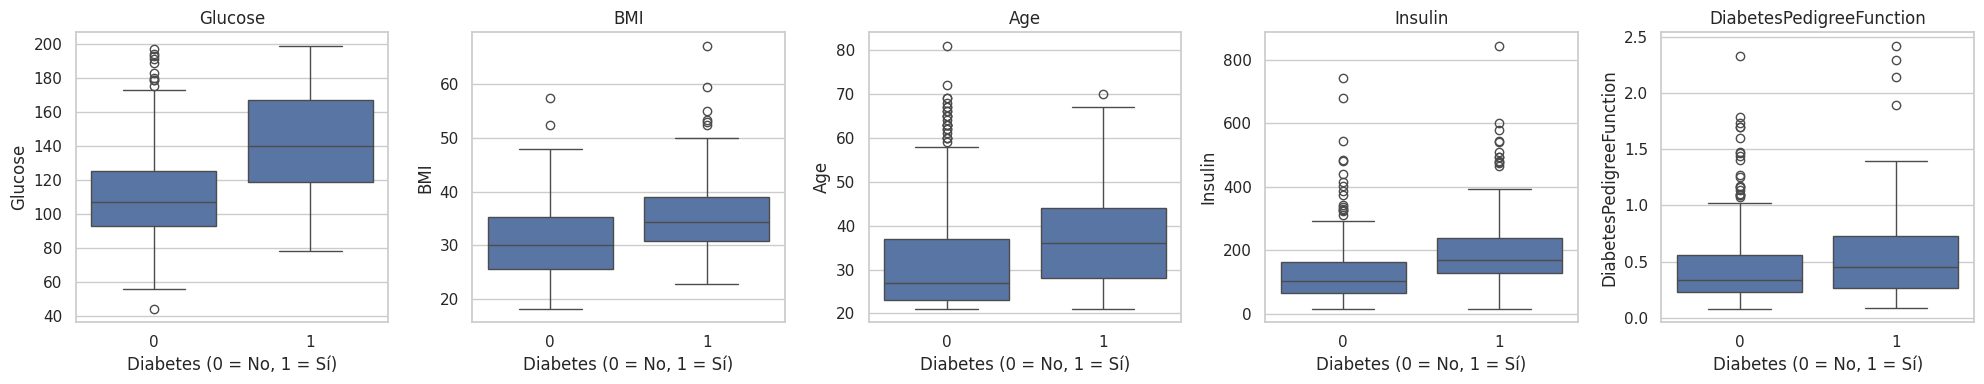

In [6]:
variables_clinicas = ["Glucose", "BMI", "Age", "Insulin", "DiabetesPedigreeFunction"]

fig, axes = plt.subplots(1, 5, figsize=(20, 4))
for ax, var in zip(axes, variables_clinicas):
    sns.boxplot(x="Outcome", y=var, data=df_clean, ax=ax)
    ax.set_title(var)
    ax.set_xlabel("Diabetes (0 = No, 1 = Sí)")
plt.tight_layout()
plt.savefig("fig05_boxplots_por_outcome.png", dpi=150)
plt.show()

In [7]:
resultados = []
for var in variables_clinicas:
    grupo_sano = df_clean.loc[df_clean["Outcome"] == 0, var].dropna()
    grupo_diabetico = df_clean.loc[df_clean["Outcome"] == 1, var].dropna()
    _, p_valor = stats.mannwhitneyu(grupo_sano, grupo_diabetico)
    resultados.append({
        "Variable": var,
        "Mediana sin diabetes": round(grupo_sano.median(), 2),
        "Mediana con diabetes": round(grupo_diabetico.median(), 2),
        "p-valor": f"{p_valor:.2e}"
    })

tabla_contrastes = pd.DataFrame(resultados)
print(tabla_contrastes.to_string(index=False))

                Variable  Mediana sin diabetes  Mediana con diabetes  p-valor
                 Glucose                107.00                140.00 1.31e-40
                     BMI                 30.10                 34.30 1.82e-17
                     Age                 27.00                 36.00 1.14e-17
                 Insulin                102.50                169.50 7.48e-14
DiabetesPedigreeFunction                  0.34                  0.45 1.20e-06


Las cinco variables muestran diferencias significativas entre grupos, y la más contundente con diferencia es la glucosa: la mediana pasa de 107 mg/dL en las pacientes sin diabetes a 140 en las diagnosticadas, con un p-valor del orden de 10⁻⁴⁰. Ese salto es enorme y era esperable, porque la glucemia es el criterio diagnóstico de la propia enfermedad.

### **2.2. Relaciones entre variables predictoras**

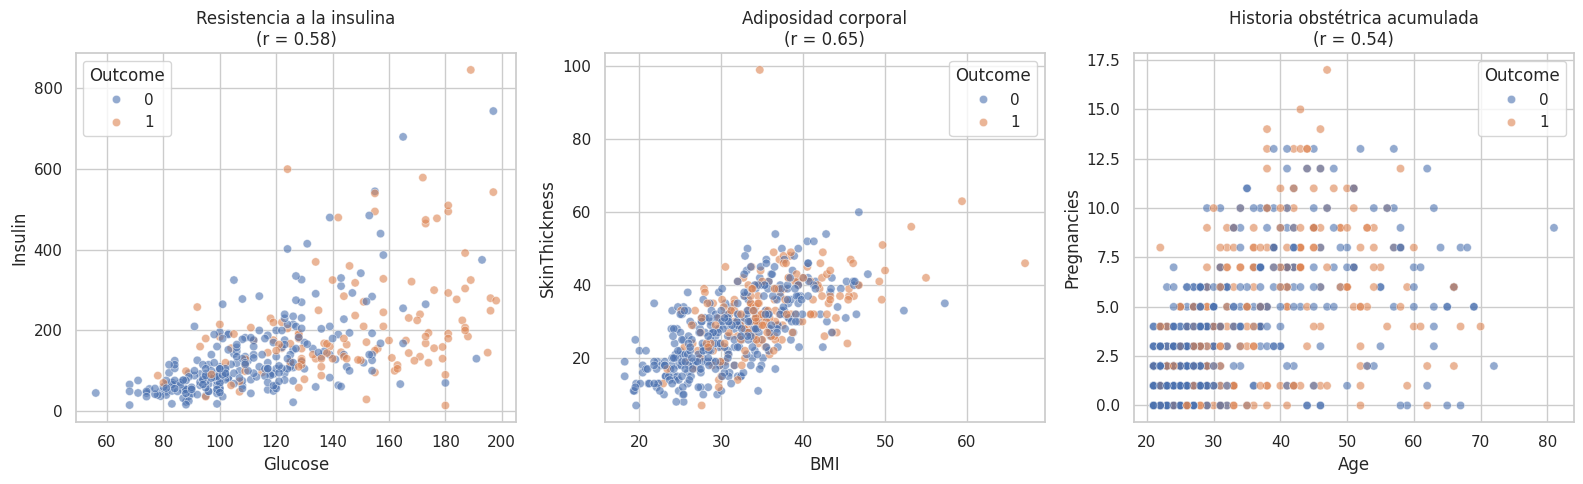

In [8]:
pares_clinicos = [
    ("Glucose", "Insulin", "Resistencia a la insulina"),
    ("BMI", "SkinThickness", "Adiposidad corporal"),
    ("Age", "Pregnancies", "Historia obstétrica acumulada"),
]

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
for ax, (x, y, titulo) in zip(axes, pares_clinicos):
    sns.scatterplot(x=x, y=y, hue="Outcome", data=df_clean, alpha=0.6, ax=ax)
    r = df_clean[[x, y]].corr().iloc[0, 1]
    ax.set_title(f"{titulo}\n(r = {r:.2f})")
plt.tight_layout()
plt.savefig("fig06_relaciones_entre_predictoras.png", dpi=150)
plt.show()

* Glucosa e insulina correlacionan a 0.58, refleja el patrón de resistencia a la insulina donde el páncreas segrega más hormona sin conseguir bajar la glucemia.
* IMC y espesor del pliegue cutáneo llegan a 0.65, la más alta de las tres, algo lógico porque las dos miden lo mismo por vías distintas.
* Edad y número de embarazos correlacionan a 0,54, una colinealidad moderada.

## **3. Análisis exploratorio de datos (EDA)**


El análisis exploratorio no es un trámite descriptivo previo al modelado, sino la fase donde se establece la **validez de los datos** sobre los que se sostendrá todo lo demás.

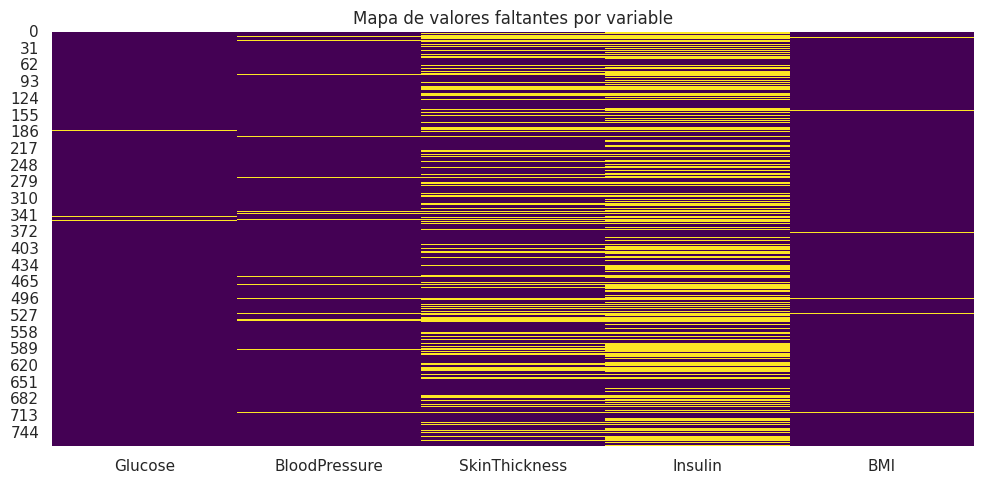

In [9]:
plt.figure(figsize=(10, 5))
sns.heatmap(df_clean[cols_con_ceros_invalidos].isnull(), cbar=False, cmap="viridis")
plt.title("Mapa de valores faltantes por variable")
plt.tight_layout()
plt.savefig("fig01_mapa_missing.png", dpi=150)
plt.show()

El mapa revela que las ausencias de SkinThickness e Insulin coinciden en los mismos registros, afirmando que a un subgrupo de pacientes no se le aplicó el protocolo completo de pruebas.

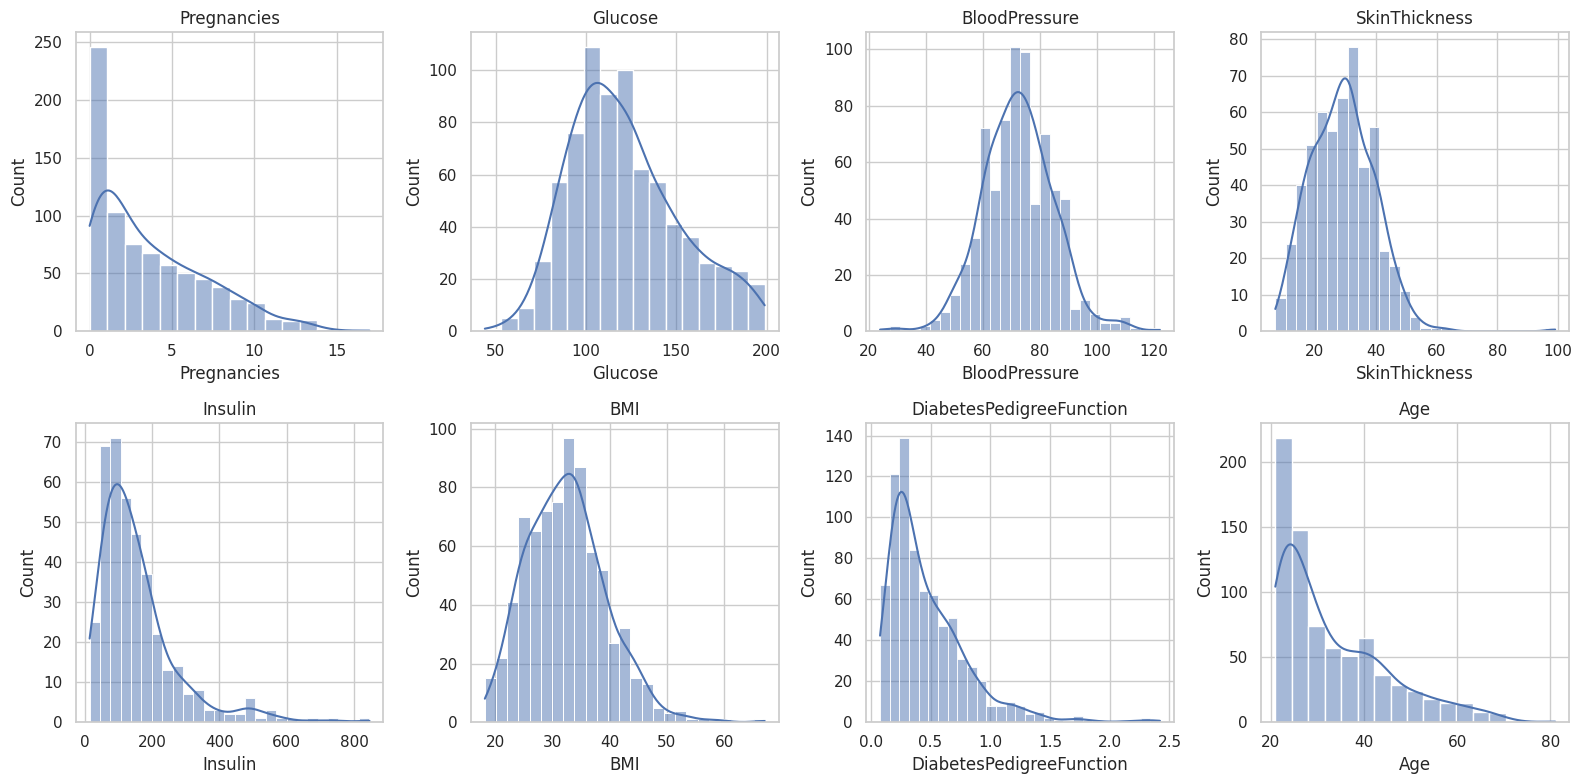

In [10]:
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
for ax, col in zip(axes.flatten(), df.columns[:-1]):
    sns.histplot(df_clean[col].dropna(), kde=True, ax=ax)
    ax.set_title(col)
plt.tight_layout()
plt.savefig("fig02_distribuciones.png", dpi=150)
plt.show()

Insulin, DiabetesPedigreeFunction, Age y Pregnancies muestran una clara asimetría positiva, con una cola larga hacia la derecha. Esto no es un defecto de los datos sino una realidad clínica: la mayoría de pacientes tiene valores moderados y unas pocas presentan cifras muy elevadas.

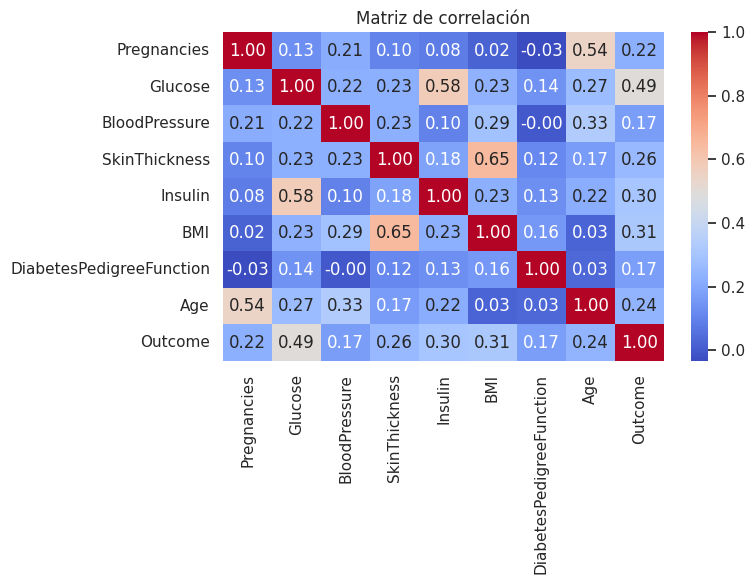

In [11]:
plt.figure(figsize=(8, 6))
sns.heatmap(df_clean.corr(), annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Matriz de correlación")
plt.tight_layout()
plt.savefig("fig03_correlacion.png", dpi=150)
plt.show()

Los tres valores más altos que se ven son precisamente los que tienen sentido fisiológico: BMI con SkinThickness (0,65), Glucose con Insulin (0,58) y Pregnancies con Age (0,54).

Ninguna correlación alcanza niveles preocupantes de colinealidad, que suelen situarse por encima de 0.8, así que no hay motivo para eliminar variables por redundancia. También destaca que Glucose es la variable más correlacionada con Outcome (0.49), anticipando su papel predominante en el modelo.

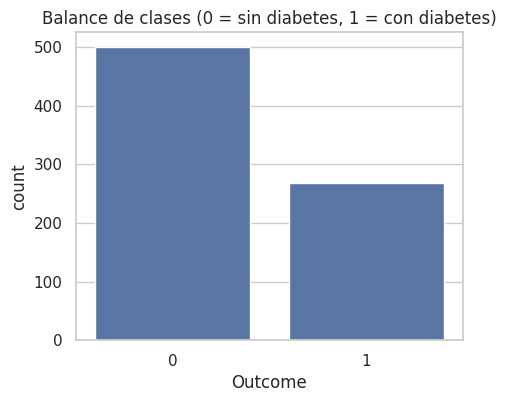

Outcome
0    0.651
1    0.349
Name: proportion, dtype: float64


In [12]:
plt.figure(figsize=(5, 4))
sns.countplot(x="Outcome", data=df_clean)
plt.title("Balance de clases (0 = sin diabetes, 1 = con diabetes)")
plt.savefig("fig04_balance_clases.png", dpi=150)
plt.show()

print(df_clean["Outcome"].value_counts(normalize=True).round(3))

El grafico anterior muestra 500 casos negativos frente a 268 positivos, es decir un 65% frente a un 35%.

 Es un desbalance moderado, no severo, pero suficiente para obligar a estratificar la partición para que ambos conjuntos mantengan la misma proporción, aconseja compensar el peso de las clases en los modelos, y sobre todo invalida la exactitud como métrica principal, y priorizar la sensibilidad y AUC.

## **4. Separación en train/test ANTES de imputar**

Este paso es crítico para evitar fuga de datos: la imputación se ajusta únicamente con el conjunto de entrenamiento y luego se aplica (transform) al test, nunca al revés.

In [13]:
# Separamos variables predictoras (X) de la variable objetivo (y).
X = df_clean.drop(columns=["Outcome"])
y = df_clean["Outcome"]

# Partición 80/20 estratificada por la variable objetivo.
# Gracias a "stratify=y" ambos conjuntos mantienen la misma proporción de pacientes con y sin diabetes.
# El uso de "random_state" permite que la partición sea reproducible.

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=RANDOM_STATE
)

print(f"Train: {X_train.shape}, Test: {X_test.shape}")
print("Proporción de clase positiva en train:", y_train.mean().round(3))
print("Proporción de clase positiva en test:", y_test.mean().round(3))

Train: (614, 8), Test: (154, 8)
Proporción de clase positiva en train: 0.349
Proporción de clase positiva en test: 0.351


El conjunto de entrenamiento queda con 614 pacientes y el de prueba con 154. La proporción de clase positiva es casi idéntica en ambos (0,349 frente a 0,351), lo que confirma que la estratificación ha funcionado y que ninguno de los dos conjuntos ha quedado sesgado hacia una clase.

## **5. Estrategia de imputación diferenciada por variable**

- Glucose, BloodPressure, BMI: missingness bajo (<5%) --> la imputación simple por **mediana** es coherente con este nivel de ausencia.
- SkinThickness (30%) e Insulin (49%): missingness alto --> **KNNImputer** es el metodo más adecuado en este caso, ya que estima el valor faltante a partir de los pacientes más similares en el resto de variables.

Todo esto se encapsulado en ColumnTransformer dentro de un Pipeline para que el ajuste ocurra solo sobre X_train.

In [14]:
# Agrupamos las variables según su tratamiento de imputación.
vars_missing_bajo = ["Glucose", "BloodPressure", "BMI"]
vars_missing_alto = ["SkinThickness", "Insulin"]
vars_sin_missing = ["Pregnancies", "DiabetesPedigreeFunction", "Age"]

# ColumnTransformer: aplica una transformación distinta a cada grupo de columnas.
preprocesador = ColumnTransformer(transformers=[
    ("imputacion_simple", SimpleImputer(strategy="median"), vars_missing_bajo),
    ("imputacion_knn", KNNImputer(n_neighbors=5), vars_missing_alto), # "n_neighbors=5" (hiperparámentro ajustable): el algoritmo busca las 5 pacientes más parecidas en el resto de variables y promedia sus valores.
    ("passthrough", "passthrough", vars_sin_missing),
])

# Pipeline: primero imputa, luego escala todas las variables a la misma magnitud
pipeline_preprocesamiento = Pipeline(steps=[
    ("preprocesador", preprocesador),
    ("escalado", StandardScaler()),
])

# fit_transform en train -> APRENDE los parámetros (medianas, vecinos) y transforma.
# transform en test      -> SOLO APLICA lo aprendido, sin recalcular nada, impidiendo la fuga de datos.
X_train_procesado = pipeline_preprocesamiento.fit_transform(X_train)
X_test_procesado = pipeline_preprocesamiento.transform(X_test)

print("Forma final tras preprocesamiento (train):", X_train_procesado.shape)

Forma final tras preprocesamiento (train): (614, 8)


Ahora, para comparar los datos imputados y no imputados, y tenga sentido, conservaremos las unidades reales de la insulina (µU/mL), sin aplicar el escalado. Si comparásemos sobre los datos ya escalados, verías números sin significado clínico. Por eso aquí uso solo la parte de imputación del pipeline, no el StandardScaler. Y trabajo solo sobre el train, que es donde el imputador aprende, para no tocar el test.

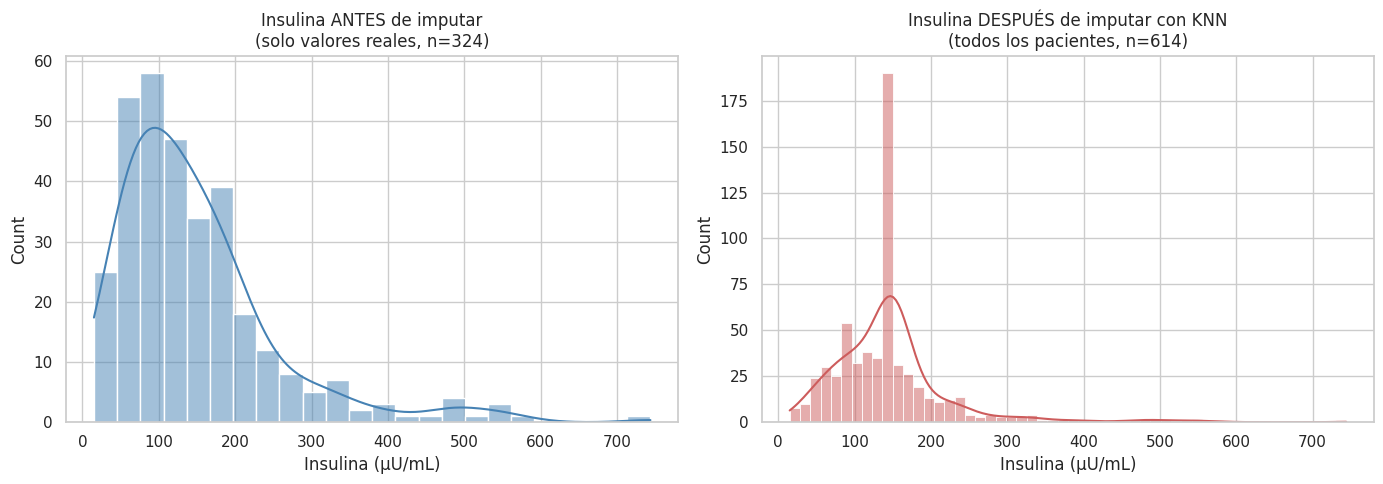

ANTES  -> media: 149.1 | mediana: 125.0 | desv. típica: 107.2
DESPUÉS-> media: 146.3 | mediana: 149.1 | desv. típica: 81.3
Valores imputados: 290


In [15]:
from sklearn.compose import ColumnTransformer

# Imputador aislado (sin escalado) para comparar en las unidades reales de insulina.
imputador_solo = ColumnTransformer(transformers=[
    ("imputacion_simple", SimpleImputer(strategy="median"), vars_missing_bajo),
    ("imputacion_knn", KNNImputer(n_neighbors=5), vars_missing_alto),
    ("passthrough", "passthrough", vars_sin_missing),
])

# Ajuste solo sobre train y reconstrucción del DataFrame con nombres de columna.
cols_salida = vars_missing_bajo + vars_missing_alto + vars_sin_missing
X_train_imputado = pd.DataFrame(
    imputador_solo.fit_transform(X_train),
    columns=cols_salida, index=X_train.index
)

# Distribución de Insulina antes (solo valores reales) y después (ya imputada).
insulina_antes = X_train["Insulin"].dropna()
insulina_despues = X_train_imputado["Insulin"]

fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharex=True)
sns.histplot(insulina_antes, kde=True, ax=axes[0], color="steelblue")
axes[0].set_title(f"Insulina ANTES de imputar\n(solo valores reales, n={insulina_antes.shape[0]})")
axes[0].set_xlabel("Insulina (µU/mL)")

sns.histplot(insulina_despues, kde=True, ax=axes[1], color="indianred")
axes[1].set_title(f"Insulina DESPUÉS de imputar con KNN\n(todos los pacientes, n={insulina_despues.shape[0]})")
axes[1].set_xlabel("Insulina (µU/mL)")

plt.tight_layout()
plt.savefig("fig07_insulina_antes_despues.png", dpi=150)
plt.show()

# Comparación numérica de la distribución.
print("ANTES  -> media:", round(insulina_antes.mean(),1),
      "| mediana:", round(insulina_antes.median(),1),
      "| desv. típica:", round(insulina_antes.std(),1))
print("DESPUÉS-> media:", round(insulina_despues.mean(),1),
      "| mediana:", round(insulina_despues.median(),1),
      "| desv. típica:", round(insulina_despues.std(),1))
print("Valores imputados:", X_train["Insulin"].isna().sum())

Es importante analizar el antes y el después de la imputación centrándonos en la insulina porque es, con diferencia, la variable con más datos faltantes (casi el 49%).

Es el caso más exigente: si la imputación mantiene la distribución aquí, donde se rellenan 290 de 614 valores, el resto de variables, con porcentajes de ausencia mucho menores, quedan cubiertas por el mismo razonamiento. Además, es la variable cuya fiabilidad más conviene vigilar, ya que un volumen tan alto de valores estimados podría condicionar su peso posterior en el modelo.

El pico que se observa tras imputar refleja que el KNN concentra las estimaciones en la zona central de la distribución al rellenar 290 valores. Aun así es la mejor opción, ya que la imputación por mediana habría dado el mismo número a todas esas pacientes, produciendo un pico aún más pronunciado y anulando su variabilidad.


# ***Bloque 2: Modelado predictivo y evaluación clínica***

Partiendo del pipeline de preprocesamiento validado en el bloque anterior, en esta fase comparamos varios algoritmos de clasificación en igualdad de condiciones, seleccionamos y ajustamos el más adecuado, y evaluamos su rendimiento sobre el conjunto de test reservado. El preprocesamiento se integra como primer paso de cada modelo, de modo que la imputación y el escalado se reajustan dentro de cada partición de la validación cruzada, evitando cualquier fuga de datos.

## **6. Preparación del modelado**

In [16]:
from sklearn.model_selection import StratifiedKFold, cross_validate, GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (classification_report, confusion_matrix, roc_auc_score,
                             roc_curve, precision_recall_curve, RocCurveDisplay,
                             ConfusionMatrixDisplay, recall_score)

# Utilizamos validación cruzada estratificada para mantener la proporción de clases en cada partición.
# Es la elección adecuada para un dataset pequeño y con clases desbalanceadas.
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

Definimos la estrategia de validación cruzada estratificada en 5 particiones, respetando de esta forma el desbalanceo de clases en cada iteración y aprovechando lo mejor posible el dataset de tamaño moderado.

In [17]:
# Comprobamos como la validación cruzada estratificada mantiene el % de diabéticas estable en cada partición.

from sklearn.model_selection import KFold

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
kf  = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

prop_estrat = [round(y_train.iloc[test].mean(), 3) for _, test in skf.split(X_train, y_train)]
prop_normal = [round(y_train.iloc[test].mean(), 3) for _, test in kf.split(X_train)]

print("Proporción de diabéticas por partición:")
print("  Con estratificación:", prop_estrat)
print("  Sin estratificación:", prop_normal)

Proporción de diabéticas por partición:
  Con estratificación: [np.float64(0.35), np.float64(0.35), np.float64(0.35), np.float64(0.35), np.float64(0.344)]
  Sin estratificación: [np.float64(0.309), np.float64(0.325), np.float64(0.407), np.float64(0.317), np.float64(0.385)]


Antes de comparar modelos conviene fijar bien cómo vamos a medirlos. Usamos validación cruzada estratificada por dos motivos que se ven en los datos:

- El primero es que troceamos la muestra manteniendo en cada parte el mismo porcentaje de pacientes con diabetes, en torno al 35%, cosa que sin estratificar no se cumple y hace que algunas particiones queden desequilibradas. Esto supone un problema, porque si a un trozo le tocan por azar pocas diabéticas, el modelo se evalúa sobre un grupo que no representa bien la realidad, y la nota que sacas de ahí no es de fiar.

- El segundo es que evaluar con una única partición sería arriesgado con tan pocos pacientes. La validación cruzada parte los datos en cinco, entrena con cuatro partes y evalúa con la quinta, y va rotando hasta que cada paciente ha servido tanto para entrenar como para evaluar, en momentos distintos. Así usas toda la muestra para las dos cosas, sin desperdiciar nada.
En vez de fiarlo todo a una tirada, hace cinco y te da la media.

In [18]:
# Segundo: ¿por qué CV y no una sola partición? Repetimos un hold-out
# simple con 10 semillas y vemos cuánto baila el resultado por puro azar.
from sklearn.metrics import roc_auc_score
from sklearn.model_selection import cross_val_score

pipe_lr = Pipeline([("preprocesamiento", pipeline_preprocesamiento),
                    ("clasificador", LogisticRegression(max_iter=1000,
                     class_weight="balanced", random_state=RANDOM_STATE))])

aucs = []
for semilla in range(10):
    xa, xb, ya, yb = train_test_split(X_train, y_train, test_size=0.2,
                                      stratify=y_train, random_state=semilla)
    pipe_lr.fit(xa, ya)
    aucs.append(roc_auc_score(yb, pipe_lr.predict_proba(xb)[:, 1]))

scores_cv = cross_val_score(pipe_lr, X_train, y_train, cv=skf, scoring="roc_auc")

print(f"Una sola partición: el AUC varía de {min(aucs):.3f} a {max(aucs):.3f} según el azar.")
print(f"Validación cruzada: AUC medio {scores_cv.mean():.3f} (variación de solo ±{scores_cv.std():.3f}).")

Una sola partición: el AUC varía de 0.802 a 0.888 según el azar.
Validación cruzada: AUC medio 0.844 (variación de solo ±0.015).


El contraste deja claro el problema de fiarlo todo a una sola partición: el AUC baila casi nueve centésimas según la suerte del reparto, de 0,802 a 0,888. La validación cruzada corrige eso promediando cinco evaluaciones, y por eso su AUC medio de 0,844 es un valor mucho más estable y creíble para comparar los modelos.

## **7. Entrenamiento y comparación de modelos**

In [19]:
# Reutilizamos los mismos cinco algoritmos que planteamos en el apartado anterior,
# aplicando class_weight="balanced" en los que lo admiten, ya que el dataset
# tiene un desbalanceo real hacia la clase "no diabético" (aprox. 65/35).
modelos = {
    "Regresión Logística": LogisticRegression(max_iter=1000, class_weight="balanced", random_state=RANDOM_STATE),
    "Random Forest": RandomForestClassifier(class_weight="balanced", random_state=RANDOM_STATE),
    "SVM (kernel RBF)": SVC(probability=True, class_weight="balanced", random_state=RANDOM_STATE),
    "KNN": KNeighborsClassifier(),  # KNN no admite class_weight, no tiene ese parámetro
    "Gradient Boosting": GradientBoostingClassifier(random_state=RANDOM_STATE)  # tampoco lo admite
}

# Métricas de interés en un contexto clínico: además de accuracy y AUC,
# nos importa mucho el recall (sensibilidad), porque un falso negativo
# en diabetes es más grave que un falso positivo.
metricas = ["roc_auc", "accuracy", "recall", "precision", "f1"]

resultados = []

for nombre, modelo in modelos.items():
    pipe = Pipeline([
        ("preprocesamiento", pipeline_preprocesamiento),
        ("clasificador", modelo)
    ])

    cv_resultado = cross_validate(
        pipe,
        X_train, y_train,
        cv=skf,
        scoring=metricas,
        n_jobs=-1
    )

    fila = {"Modelo": nombre}
    for m in metricas:
        media = cv_resultado[f"test_{m}"].mean()
        desviacion = cv_resultado[f"test_{m}"].std()
        fila[m] = f"{media:.3f} ± {desviacion:.3f}"
        fila[f"{m}_ord"] = media  # columna auxiliar solo para poder ordenar la tabla

    resultados.append(fila)

tabla_comparativa = pd.DataFrame(resultados).sort_values("roc_auc_ord", ascending=False)
tabla_comparativa.drop(columns=[c for c in tabla_comparativa.columns if c.endswith("_ord")], inplace=False)

,Modelo,roc_auc,accuracy,recall,precision,f1
0,Regresión Logística,0.844 ± 0.015,0.764 ± 0.010,0.706 ± 0.042,0.650 ± 0.025,0.675 ± 0.013
2,SVM (kernel RBF),0.835 ± 0.030,0.762 ± 0.032,0.762 ± 0.049,0.641 ± 0.063,0.692 ± 0.020
1,Random Forest,0.820 ± 0.022,0.765 ± 0.030,0.565 ± 0.070,0.705 ± 0.052,0.625 ± 0.057
4,Gradient Boosting,0.812 ± 0.020,0.748 ± 0.032,0.593 ± 0.031,0.659 ± 0.073,0.622 ± 0.032
3,KNN,0.788 ± 0.045,0.728 ± 0.050,0.565 ± 0.044,0.633 ± 0.101,0.594 ± 0.057


En esta celda se entrena cada uno de los cinco algoritmos dentro del mismo pipeline de preprocesamiento, usando la validación cruzada estratificada de 5 particiones definida antes. Para cada modelo se calculan cinco métricas (ROC-AUC, accuracy, recall, precision y F1) y se muestra la media junto con la desviación típica entre particiones, ordenando la tabla por ROC-AUC de mayor a menor.

La Regresión Logística queda en primer lugar con un ROC-AUC de 0,844, seguida muy de cerca por el SVM con 0,835. Lo interesante no es solo el orden por AUC, sino que el SVM saca un recall notablemente más alto (0,762 frente a 0,706 de la Regresión Logística), aunque a costa de algo de precisión. Esto ya apunta a que ambos modelos son los principales candidatos.

KNN es el que peor se comporta en todas las métricas, con el AUC más bajo (0,788) y también la mayor variabilidad entre particiones, lo que sugiere que es el modelo menos estable de los cinco para este dataset.

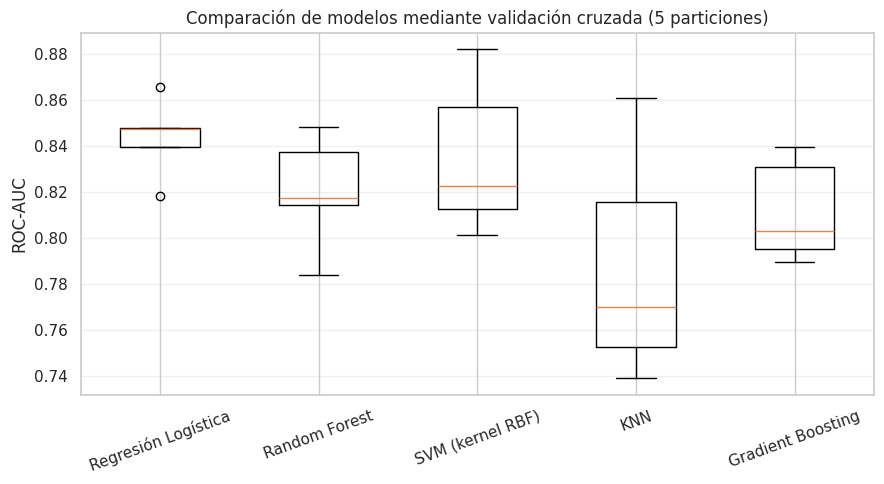

In [20]:
# Boxplot comparando la distribución del AUC entre los 5 folds para cada modelo,
# igual que hicimos antes con la Regresión Logística sola, pero ahora para los cinco.

aucs_por_modelo = {}
for nombre, modelo in modelos.items():
    pipe = Pipeline([
        ("preprocesamiento", pipeline_preprocesamiento),
        ("clasificador", modelo)
    ])
    aucs_por_modelo[nombre] = cross_val_score(pipe, X_train, y_train, cv=skf, scoring="roc_auc")

plt.figure(figsize=(9, 5))
plt.boxplot(aucs_por_modelo.values(), tick_labels=aucs_por_modelo.keys())
plt.ylabel("ROC-AUC")
plt.title("Comparación de modelos mediante validación cruzada (5 particiones)")
plt.xticks(rotation=20)
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.savefig("fig08_comparacion_modelos_boxplot.png", dpi=300, bbox_inches="tight")
plt.show()

El gráfico confirma lo que ya se veía en la tabla: la Regresión Logística tiene la caja más estrecha y más alta de las cinco, lo que indica que su rendimiento es el más consistente entre particiones, sin apenas variación. El SVM y Random Forest muestran cajas más anchas, con un rango que llega a superponerse con la Regresión Logística en el extremo superior pero también baja más en el inferior. KNN es, de nuevo, el modelo con mayor dispersión y el que peor mediana presenta, reforzando la idea de que es el candidato menos fiable de los cinco para seguir adelante.

## **8. Optimización de hiperparámetros**

Antes de entrenar un modelo hay que decidir ciertos ajustes internos, llamados hiperparámetros, que no se aprenden de los datos sino que se fijan de antemano y condicionan cómo se comporta el algoritmo. GridSearchCV permite probar de forma automática varias combinaciones de estos ajustes y quedarse con la que mejor resultado da, en lugar de fijarlos a mano por intuición.

Se aplica el GridSearchCV a los dos modelos que mejor resultado dieron en la comparación anterior, la Regresión Logística y el SVM. Se prueban distintas combinaciones de hiperparámetros usando las mismas 5 particiones estratificadas de siempre, y se selecciona la combinación que maximiza el ROC-AUC medio.

En la Regresión Logística se ajustan el parámetro de regularización C y el tipo de penalización, mientras que en el SVM se ajustan C y gamma, que regula la flexibilidad del kernel RBF.

In [21]:
# Rejilla de hiperparámetros para la Regresión Logística.
# Probamos distintos valores de regularización (C) y dos tipos de penalización.
# El solver "liblinear" admite tanto l1 como l2, por eso lo fijamos para toda la rejilla.
param_grid_lr = {
    "clasificador__C": [0.01, 0.1, 1, 10, 100],
    "clasificador__penalty": ["l1", "l2"],
    "clasificador__solver": ["liblinear"]
}

pipe_lr = Pipeline([
    ("preprocesamiento", pipeline_preprocesamiento),
    ("clasificador", LogisticRegression(max_iter=1000, class_weight="balanced", random_state=RANDOM_STATE))
])

grid_lr = GridSearchCV(
    pipe_lr,
    param_grid=param_grid_lr,
    scoring="roc_auc",
    cv=skf,
    n_jobs=-1
)
grid_lr.fit(X_train, y_train)

print("Mejores hiperparámetros (Regresión Logística):", grid_lr.best_params_)
print(f"Mejor ROC-AUC en validación cruzada: {grid_lr.best_score_:.3f}")

Mejores hiperparámetros (Regresión Logística): {'clasificador__C': 0.1, 'clasificador__penalty': 'l2', 'clasificador__solver': 'liblinear'}
Mejor ROC-AUC en validación cruzada: 0.845


In [22]:
# Rejilla de hiperparámetros para el SVM.
# C controla la penalización por error, gamma la influencia de cada punto de entrenamiento.
param_grid_svm = {
    "clasificador__C": [0.1, 1, 10, 100],
    "clasificador__gamma": ["scale", 0.01, 0.1, 1],
    "clasificador__kernel": ["rbf"]
}

pipe_svm = Pipeline([
    ("preprocesamiento", pipeline_preprocesamiento),
    ("clasificador", SVC(probability=True, class_weight="balanced", random_state=RANDOM_STATE))
])

grid_svm = GridSearchCV(
    pipe_svm,
    param_grid=param_grid_svm,
    scoring="roc_auc",
    cv=skf,
    n_jobs=-1
)
grid_svm.fit(X_train, y_train)

print("Mejores hiperparámetros (SVM):", grid_svm.best_params_)
print(f"Mejor ROC-AUC en validación cruzada: {grid_svm.best_score_:.3f}")

Mejores hiperparámetros (SVM): {'clasificador__C': 1, 'clasificador__gamma': 0.01, 'clasificador__kernel': 'rbf'}
Mejor ROC-AUC en validación cruzada: 0.849


In [23]:
# Comparativa final entre los dos modelos ya optimizados, incluyendo recall,
# ya que es la métrica que más nos importa desde el punto de vista clínico.

from sklearn.model_selection import cross_val_score

modelos_optimizados = {
    "Regresión Logística (optimizada)": grid_lr.best_estimator_,
    "SVM (optimizado)": grid_svm.best_estimator_
}

resumen_optimizacion = []
for nombre, modelo in modelos_optimizados.items():
    auc = cross_val_score(modelo, X_train, y_train, cv=skf, scoring="roc_auc").mean()
    recall = cross_val_score(modelo, X_train, y_train, cv=skf, scoring="recall").mean()
    resumen_optimizacion.append({"Modelo": nombre, "ROC-AUC": round(auc, 3), "Recall": round(recall, 3)})

tabla_optimizacion = pd.DataFrame(resumen_optimizacion)
tabla_optimizacion

,Modelo,ROC-AUC,Recall
0,Regresión Logística (optimizada),0.845,0.72
1,SVM (optimizado),0.849,0.72


La Regresión Logística obtiene su mejor resultado con C=0.1 y penalización l2, subiendo apenas de 0.844 a 0.845 de ROC-AUC. El SVM mejora algo más, de 0.835 a 0.849, con C=1 y gamma=0.01, quedando ligeramente por delante en esta métrica. Sin embargo, ambos modelos igualan su recall en 0.72, así que en la capacidad de detectar pacientes diabéticos no hay diferencia entre ellos.

El SVM tiene algo más de discriminación global, pero la Regresión Logística resulta más interpretable, algo relevante en un entorno hospitalario real. Por eso no se descarta ninguno de los dos todavía, y la decisión final se deja para el siguiente apartado, donde la matriz de confusión, la curva ROC y el ajuste del umbral clínico aportarán más criterio para elegir el modelo definitivo.

## **9. Evaluación completa: matriz de confusión y curva ROC**

Hasta ahora todos los números que hemos manejado venían de la validación cruzada, es decir, de datos que en algún momento formaron parte del entrenamiento, pero en este apartado entrenamos cada modelo con todo el conjunto de train y lo evaluamos contra el test, que no ha intervenido en ninguna decisión anterior.

Es la prueba real para ver si los modelos generalizan o solo se veían bien porque los estábamos midiendo con "trampa". Se sacan el informe de clasificación, las matrices de confusión y las curvas ROC de los dos candidatos, Regresión Logística y SVM.

In [24]:
# Entrenamos cada modelo con TODO el conjunto de train (ya no hace falta seguir
# dividiendo en folds, ya que se cumplió su función en la fase de selección).

grid_lr.best_estimator_.fit(X_train, y_train)
grid_svm.best_estimator_.fit(X_train, y_train)

y_pred_lr = grid_lr.best_estimator_.predict(X_test)
y_pred_svm = grid_svm.best_estimator_.predict(X_test)

y_prob_lr = grid_lr.best_estimator_.predict_proba(X_test)[:, 1]
y_prob_svm = grid_svm.best_estimator_.predict_proba(X_test)[:, 1]

print("Regresión Logística, conjunto de test:")
print(classification_report(y_test, y_pred_lr))

print("SVM, conjunto de test:")
print(classification_report(y_test, y_pred_svm))

Regresión Logística, conjunto de test:
              precision    recall  f1-score   support

           0       0.82      0.73      0.77       100
           1       0.58      0.70      0.64        54

    accuracy                           0.72       154
   macro avg       0.70      0.72      0.71       154
weighted avg       0.74      0.72      0.73       154

SVM, conjunto de test:
              precision    recall  f1-score   support

           0       0.83      0.73      0.78       100
           1       0.59      0.72      0.65        54

    accuracy                           0.73       154
   macro avg       0.71      0.73      0.71       154
weighted avg       0.75      0.73      0.73       154



 Ambos modelos tiene una accuracy muy similar, por lo que tenemos que dar especialmente importancia es a la clase 1 (pacientes diabéticos): la Regresión Logística presenta un recall de 0,70 y el SVM sube ligeramente a 0,72, y con precision muy parecida en los dos (0,58 y 0,59). Son resultados prácticamente empatados, con el SVM minimamente superior detectando los casos positivos.

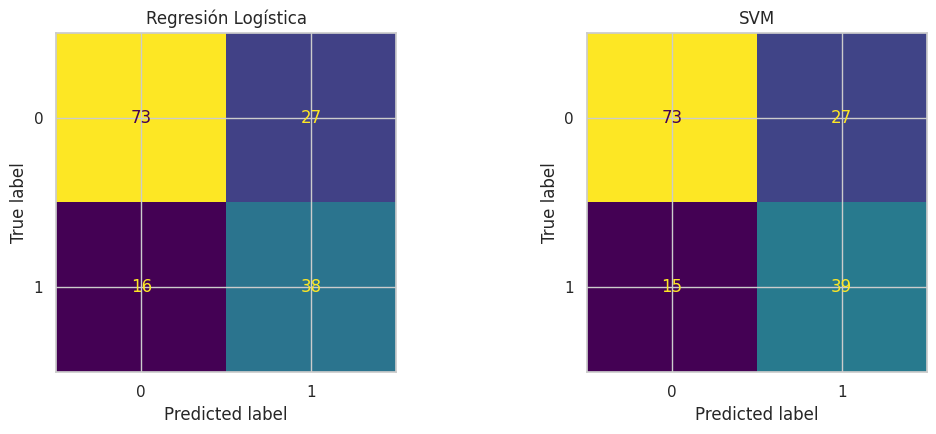

In [25]:
# Matrices de confusión de los dos modelos, una al lado de otra para compararlas facilmente.
#  TP FP
#  FN TN

fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))

ConfusionMatrixDisplay.from_predictions(y_test, y_pred_lr, ax=axes[0], colorbar=False)
axes[0].set_title("Regresión Logística")

ConfusionMatrixDisplay.from_predictions(y_test, y_pred_svm, ax=axes[1], colorbar=False)
axes[1].set_title("SVM")

plt.tight_layout()
plt.savefig("fig09_matrices_confusion.png", dpi=300, bbox_inches="tight")
plt.show()

Comparando las dos matrices de confusión, podemos ver que los dos modelos son casi identicos. La Regresión Logística acierta 38 pacientes diabéticos y se le escapan 16, el SVM acierta uno más (39) y falla 15. Un solo paciente de diferencia. Y en los falsos positivos coinciden exactamente 27 en los dos. Objetivamente, mirando solo esta matriz no encuentro ningún argumento fuerte para quedarme con uno de los dos modelos.

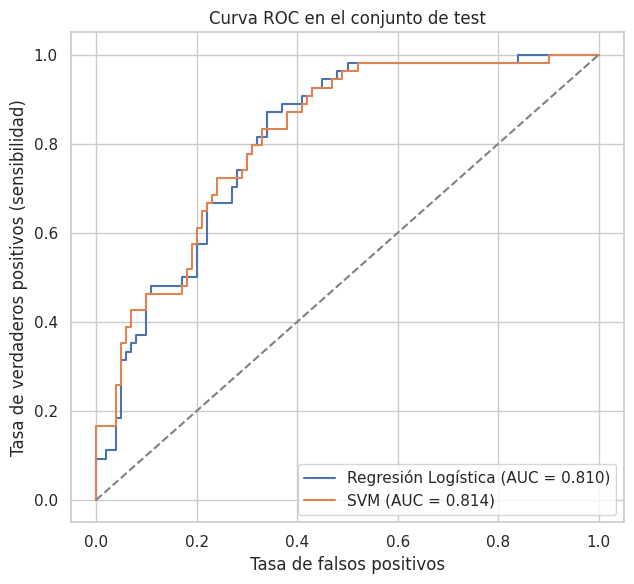

In [26]:
# Curvas ROC de ambos modelos sobre el conjunto de test.

fpr_lr, tpr_lr, _ = roc_curve(y_test, y_prob_lr)
fpr_svm, tpr_svm, _ = roc_curve(y_test, y_prob_svm)

auc_lr_test = roc_auc_score(y_test, y_prob_lr)
auc_svm_test = roc_auc_score(y_test, y_prob_svm)

plt.figure(figsize=(6.5, 6))
plt.plot(fpr_lr, tpr_lr, label=f"Regresión Logística (AUC = {auc_lr_test:.3f})")
plt.plot(fpr_svm, tpr_svm, label=f"SVM (AUC = {auc_svm_test:.3f})")
plt.plot([0, 1], [0, 1], linestyle="--", color="gray")
plt.xlabel("Tasa de falsos positivos")
plt.ylabel("Tasa de verdaderos positivos (sensibilidad)")
plt.title("Curva ROC en el conjunto de test")
plt.legend()
plt.tight_layout()
plt.savefig("fig10_curva_roc_test.png", dpi=300, bbox_inches="tight")
plt.show()

Las dos curvas van prácticamente pegadas durante todo el recorrido, con el SVM ligeramente por encima en algunos tramos. El AUC de test confirma lo mismo que ya veíamos en la validación cruzada: 0,810 para la Regresión Logística y 0,814 para el SVM, una diferencia mínima que no permite hablar de un modelo claramente superior, aunque el SVM es ligeramente superir en TODAS las métricas.

## **10. Ajuste del umbral de decisión para reducir falsos negativos**

En un problema donde un falso negativo significa mandar a casa a una paciente diabética sin diagnosticar, tiene mucho más sentido bajar ese umbral y aceptar algunos falsos positivos de más a cambio de pillar a más pacientes reales.

El umbral de 0.5 que usa un modelo por defecto no viene de ninguna consideración médica, es solo el punto medio entre las dos clases. Para mejor la predicción, lo movemos a propósito buscando, para cada modelo, el umbral más bajo posible que nos garantice al menos un 85% de recall, es decir, que el modelo detecte al menos a 85 de cada 100 pacientes diabéticas reales.

Para calcular ese umbral hay que tener cuidado con un detalle que puede pasar desapercibido, y es que no podemos usar el conjunto de test para decidirlo. El test tiene que quedar reservado únicamente para dar la cifra final de rendimiento, y si lo usamos también para elegir el umbral, estamos tomando una decisión con información que en teoría no deberíamos conocer todavía.

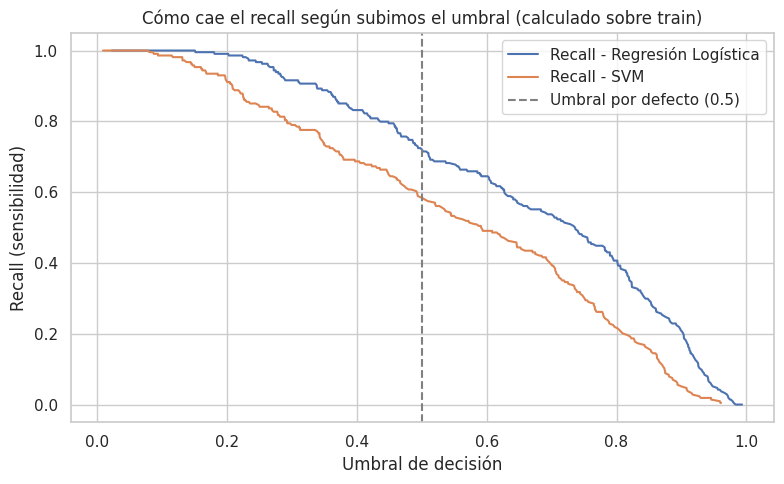

In [27]:
# Para cada modelo, calculamos precision, recall y umbral asociado en todo el rango posible.

from sklearn.model_selection import cross_val_predict

# En vez de predict_proba directo sobre el modelo ya entrenado con todo el train,
# usamos cross_val_predict: para cada paciente del train, la probabilidad que le asigna
# viene de un modelo que NO lo vio durante ese fold. Así simulamos "datos nuevos"
# sin tocar el test en ningún momento.
prob_lr_train_cv = cross_val_predict(
    grid_lr.best_estimator_, X_train, y_train, cv=skf, method="predict_proba"
)[:, 1]

prob_svm_train_cv = cross_val_predict(
    grid_svm.best_estimator_, X_train, y_train, cv=skf, method="predict_proba"
)[:, 1]

# Gráfico de recall según el umbral, ahora calculado sobre el train (vía CV), no sobre el test.

precision_lr_cv, recall_lr_cv, umbrales_lr_cv = precision_recall_curve(y_train, prob_lr_train_cv)
precision_svm_cv, recall_svm_cv, umbrales_svm_cv = precision_recall_curve(y_train, prob_svm_train_cv)

plt.figure(figsize=(8, 5))
plt.plot(umbrales_lr_cv, recall_lr_cv[:-1], label="Recall - Regresión Logística")
plt.plot(umbrales_svm_cv, recall_svm_cv[:-1], label="Recall - SVM")
plt.axvline(0.5, linestyle="--", color="gray", label="Umbral por defecto (0.5)")
plt.xlabel("Umbral de decisión")
plt.ylabel("Recall (sensibilidad)")
plt.title("Cómo cae el recall según subimos el umbral (calculado sobre train)")
plt.legend()
plt.tight_layout()
plt.savefig("fig11_recall_vs_umbral.png", dpi=300, bbox_inches="tight")
plt.show()

En el grafico anterior podemos ver claramente la importancia del umbral, ya que con el 0.5 de siempre, la Regresión Logística baja bastante el recall, pero el SVM lo hace incluso más rápido, mostrando una caída más marcada al pasar el umbral por defecto. La línea azul (Regresión Logística) aguanta mejor la sensibilidad conforme subimos el umbral e comparación  con la naranja (SVM), que se desploma antes.

In [28]:
# Buscamos el umbral usando el train, exactamente igual que antes pero sin tocar el test.

objetivo_recall = 0.85

def umbral_para_recall_objetivo(y_prob, y_real, objetivo):
    precision, recall, umbrales = precision_recall_curve(y_real, y_prob)
    candidatos = [(u, r) for u, r in zip(umbrales, recall[:-1]) if r >= objetivo]
    if not candidatos:
        return None
    return max(candidatos, key=lambda x: x[0])[0]

umbral_lr_ajustado = umbral_para_recall_objetivo(prob_lr_train_cv, y_train, objetivo_recall)
umbral_svm_ajustado = umbral_para_recall_objetivo(prob_svm_train_cv, y_train, objetivo_recall)

print(f"Umbral ajustado Regresión Logística (recall ≥ 85% en train): {umbral_lr_ajustado:.3f}")
print(f"Umbral ajustado SVM (recall ≥ 85% en train): {umbral_svm_ajustado:.3f}")

Umbral ajustado Regresión Logística (recall ≥ 85% en train): 0.384
Umbral ajustado SVM (recall ≥ 85% en train): 0.244


Para llegar al 85% de recall, la Regresión Logística necesita bajar el umbral hasta 0.384 y el SVM hasta 0.244.

El SVM tiene que bajar bastante más el umbral para alcanzar la misma sensibilidad, respaldando lo que se veía en la gráfica anterior, pierde recall más rápido y por eso necesita un umbral más permisivo para compensar, y llegar al mismo objetivo clínico.

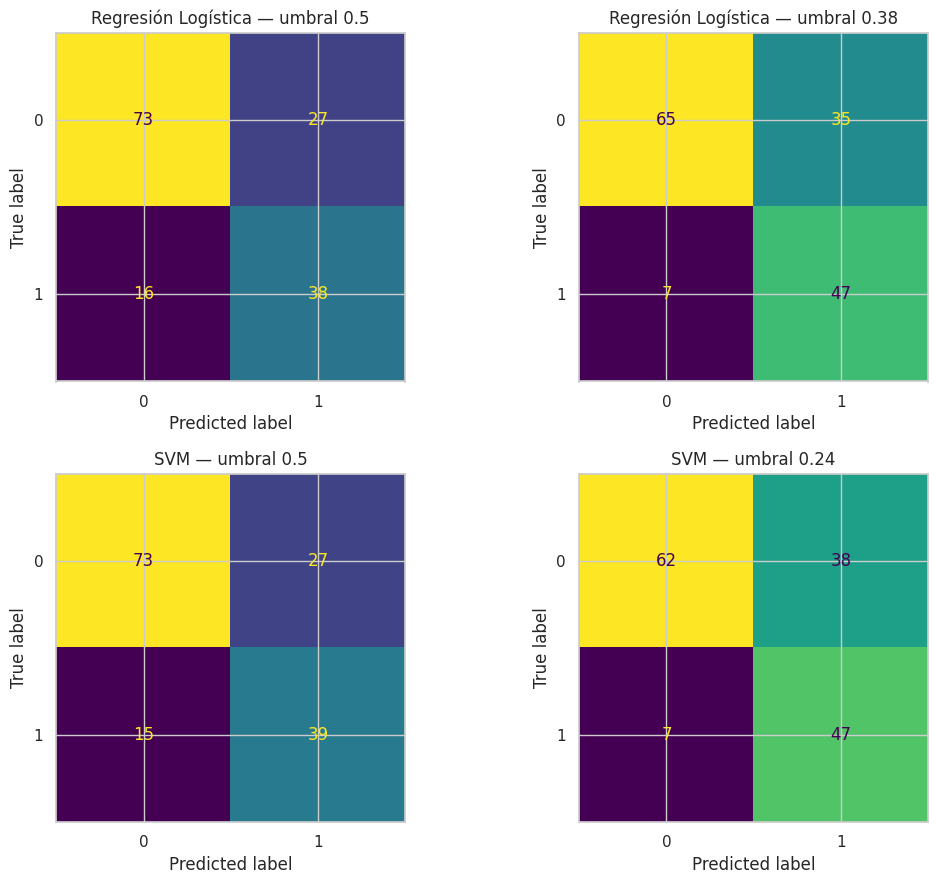

Regresión Logística, umbral ajustado:
              precision    recall  f1-score   support

           0       0.90      0.65      0.76       100
           1       0.57      0.87      0.69        54

    accuracy                           0.73       154
   macro avg       0.74      0.76      0.72       154
weighted avg       0.79      0.73      0.73       154

SVM, umbral ajustado:
              precision    recall  f1-score   support

           0       0.90      0.62      0.73       100
           1       0.55      0.87      0.68        54

    accuracy                           0.71       154
   macro avg       0.73      0.75      0.70       154
weighted avg       0.78      0.71      0.71       154



In [29]:
# Aplicamos los nuevos umbrales y comparamos matrices de confusión: antes (0.5) y después.

y_pred_lr_ajustado = (y_prob_lr >= umbral_lr_ajustado).astype(int)
y_pred_svm_ajustado = (y_prob_svm >= umbral_svm_ajustado).astype(int)

fig, axes = plt.subplots(2, 2, figsize=(11, 9))

ConfusionMatrixDisplay.from_predictions(y_test, y_pred_lr, ax=axes[0, 0], colorbar=False)
axes[0, 0].set_title("Regresión Logística — umbral 0.5")

ConfusionMatrixDisplay.from_predictions(y_test, y_pred_lr_ajustado, ax=axes[0, 1], colorbar=False)
axes[0, 1].set_title(f"Regresión Logística — umbral {umbral_lr_ajustado:.2f}")

ConfusionMatrixDisplay.from_predictions(y_test, y_pred_svm, ax=axes[1, 0], colorbar=False)
axes[1, 0].set_title("SVM — umbral 0.5")

ConfusionMatrixDisplay.from_predictions(y_test, y_pred_svm_ajustado, ax=axes[1, 1], colorbar=False)
axes[1, 1].set_title(f"SVM — umbral {umbral_svm_ajustado:.2f}")

plt.tight_layout()
plt.savefig("fig12_matrices_confusion_umbral_ajustado.png", dpi=300, bbox_inches="tight")
plt.show()

print("Regresión Logística, umbral ajustado:")
print(classification_report(y_test, y_pred_lr_ajustado))

print("SVM, umbral ajustado:")
print(classification_report(y_test, y_pred_svm_ajustado))

El cambio es contundente en los dos modelos. La Regresión Logística pasa de 16 falsos negativos a solo 7, y el SVM baja de 15 a 7 también. La diferencia entre los dos modelos aparece en el otro lado, puesto que la Regresión Logística sube sus falsos positivos de 27 a 35, mientras que el SVM sube más, de 27 a 38. Es decir, para conseguir el mismo nivel de detección de diabéticas, el SVM necesita "molestar" a tres pacientes sanas más que la Regresión Logística.

Con el umbral ajustado, ambos modelos llegan al mismo recall, 0.87. Pero la Regresión Logística mantiene mejor la precision (0.57 frente a 0.55) y un f1 algo más alto en la clase 1 (0.69 frente a 0.68). Es una diferencia pequeña, pero en igualdad de recall, que es justo lo que buscábamos priorizar, la Regresión Logística sale ganando por hacerlo con menos ruido añadido, y eso, sumado a que es más fácil de interpretar para el personal clínico, inclina bastante la balanza para escoger la Regresión Logistica como el modelo definitivo del trabajo.

## **11. Interpretabilidad del modelo definitivo**

Por último, realizaremos el más importante de la aplicación de modelos algoritmicos en entornos hospitalarios reales, que es poder explicar por qué predice lo que predice, ya que un médico no va a fiarse de una caja negra que le suelta un número, necesita entender qué variables está pesando el modelo y en qué dirección.

La forma más coherente es hacerlo en 2 niveles:
* Primero una visión global, qué variables pesan más en el modelo en conjunto, con dos métodos que se apoyan mutuamente: los coeficientes de la propia Regresión Logística y la importancia por permutación.
* Despues, una visión local con SHAP, que permite explicar casos concretos, por qué el modelo marcó a esta paciente en particular.

### **11.1. Visión global**

In [30]:
# Nos aseguramos de partir del modelo ya optimizado y entrenado con todo el train.
modelo_final = grid_lr.best_estimator_
modelo_final.fit(X_train, y_train)

# Recuperamos los nombres de las variables tal y como salen del preprocesamiento,
# para que las gráficas muestren etiquetas legibles y no "x0, x1, x2...".
nombres_variables = modelo_final.named_steps["preprocesamiento"].get_feature_names_out()
nombres_variables = [n.split("__")[-1] for n in nombres_variables]  # quitamos el prefijo del transformador

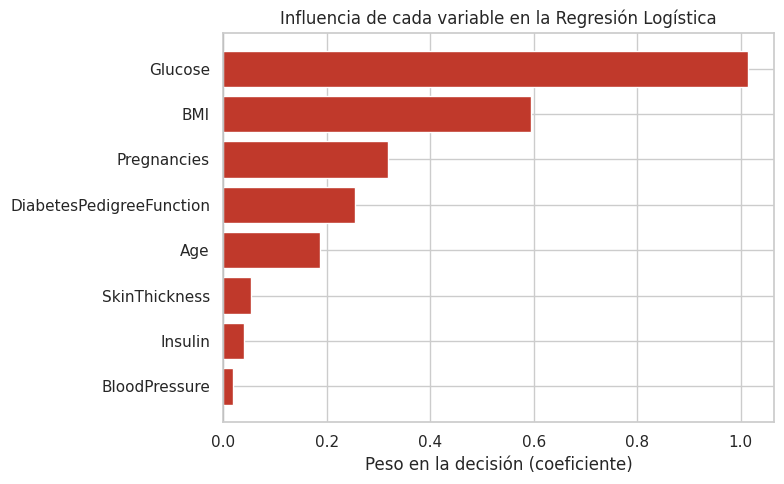

In [31]:
# Nivel 1a: Coeficientes de la Regresión Logística.

# Al haber escalado las variables antes, los coeficientes son comparables entre sí:
# un coeficiente positivo empuja hacia "diabetes", uno negativo hacia "no diabetes",
# y su magnitud indica cuánto pesa esa variable en la decisión.

coeficientes = modelo_final.named_steps["clasificador"].coef_[0]

importancia_coef = pd.DataFrame({
    "Variable": nombres_variables,
    "Coeficiente": coeficientes
}).sort_values("Coeficiente", key=abs, ascending=True)

plt.figure(figsize=(8, 5))
colores = ["#c0392b" if c > 0 else "#2874a6" for c in importancia_coef["Coeficiente"]]
plt.barh(importancia_coef["Variable"], importancia_coef["Coeficiente"], color=colores)
plt.axvline(0, color="gray", linewidth=0.8)
plt.xlabel("Peso en la decisión (coeficiente)")
plt.title("Influencia de cada variable en la Regresión Logística")
plt.tight_layout()
plt.savefig("fig13_coeficientes_regresion.png", dpi=300, bbox_inches="tight")
plt.show()

Podemos observar como claramente Glucose, es con diferencia, es la variable con mayor peso de todas, algo que clínicamente tiene todo el sentido, ya que la glucosa en sangre es literalmente el criterio con el que se diagnostica la diabetes.

Detrás aparece el IMC (BMI), que tiene total coherencia debido a la fuerte relación conocida entre obesidad y diabetes tipo 2. Luego, el número de embarazos y el antecedente familiar (DiabetesPedigreeFunction), dos factores de riesgo bien documentados en la literatura.

Todos los coeficientes son positivos, por lo tanto todas las variables empujan hacia el diagnóstico cuando suben.

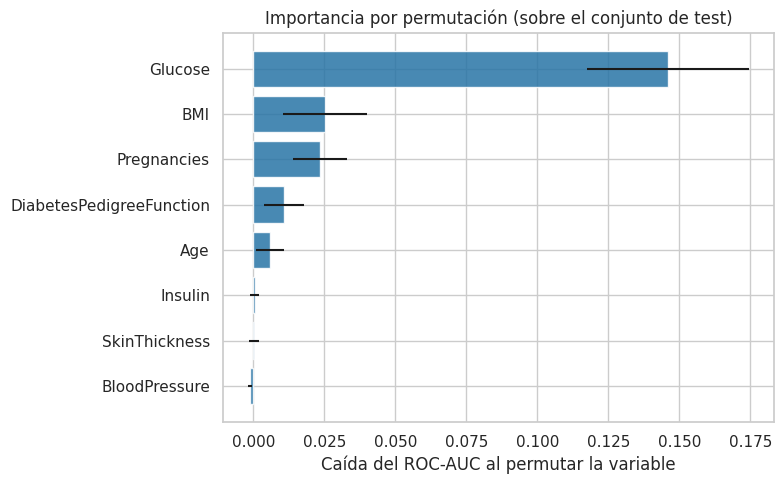

In [32]:
# Nivel 1b: Importancia por permutación.

# Mide cuánto empeora el modelo si "estropeamos" una variable barajando sus valores.
# Si al desordenar una variable el rendimiento cae mucho, es que esa variable era importante.
# La ventaja frente a los coeficientes es que no asume relación lineal y se calcula sobre el test.

from sklearn.inspection import permutation_importance

resultado_perm = permutation_importance(
    modelo_final, X_test, y_test,
    scoring="roc_auc", n_repeats=30, random_state=RANDOM_STATE, n_jobs=-1
)

importancia_perm = pd.DataFrame({
    "Variable": X_test.columns,
    "Importancia": resultado_perm.importances_mean,
    "Desviacion": resultado_perm.importances_std
}).sort_values("Importancia", ascending=True)

plt.figure(figsize=(8, 5))
plt.barh(importancia_perm["Variable"], importancia_perm["Importancia"],
         xerr=importancia_perm["Desviacion"], color="#2874a6", alpha=0.85)
plt.xlabel("Caída del ROC-AUC al permutar la variable")
plt.title("Importancia por permutación (sobre el conjunto de test)")
plt.tight_layout()
plt.savefig("fig14_importancia_permutacion.png", dpi=300, bbox_inches="tight")
plt.show()

Esta gráfica sobre la permutación, cuenta prácticamente la misma historia que la anterior, respaldando que los resultados son coherentes. Cuando dos métodos independientes coinciden en señalar a las mismas variables, el argumento se vuelve mucho más fiable.

Aquí, la Glucose también destaca de forma aplastante, seguida de BMI y Pregnancies, con un ROC-AUC que se desploma cuando desordenamos la glucosa y apenas se inmuta cuando tocamos la presión arterial. Que las dos técnicas apunten al mismo grupo de variables clave refuerza que el modelo no está aprendiendo casualidades, sino relaciones clínicas reales.

### **11.2. Visión local**

In [36]:
# Nivel 2: SHAP para explicaciones locales y globales.

# SHAP reparte, para cada paciente, cuánto ha aportado cada variable a su predicción concreta.

import shap

# Transformamos el train con el pipeline (sin el clasificador) para que SHAP trabaje
# sobre los datos ya imputados y escalados, que es lo que realmente ve el modelo.
preprocesador_ajustado = modelo_final.named_steps["preprocesamiento"]
X_train_transformado = preprocesador_ajustado.transform(X_train)
X_test_transformado = preprocesador_ajustado.transform(X_test)

clasificador_final = modelo_final.named_steps["clasificador"]

# Para un modelo lineal, LinearExplainer es el explicador adecuado y rápido.
explicador = shap.LinearExplainer(
    clasificador_final,
    shap.maskers.Independent(X_train_transformado, max_samples=X_train_transformado.shape[0]))
shap_values = explicador.shap_values(X_test_transformado)

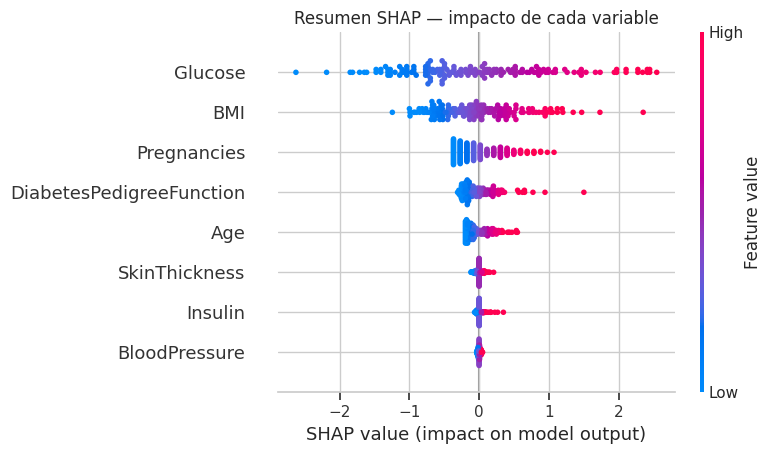

In [37]:
# Resumen global SHAP: muestra qué variables mueven más las predicciones en todo el conjunto de test.
shap.summary_plot(
    shap_values, X_test_transformado,
    feature_names=nombres_variables, show=False
)
plt.title("Resumen SHAP — impacto de cada variable")
plt.tight_layout()
plt.savefig("fig15_shap_resumen.png", dpi=300, bbox_inches="tight")
plt.show()

Aquí se ve algo que las gráficas anteriores no mostraban: no solo qué variables pesan, sino en qué dirección. En la fila de Glucose, los puntos rojos (valores altos de glucosa) se van claramente hacia la derecha, empujando la predicción hacia diabetes, mientras que los azules (glucosa baja) tiran hacia la izquierda. El mismo patrón se repite con el IMC. Es exactamente el comportamiento que esperaríamos de un modelo clínicamente coherente, a más glucosa y más IMC, más riesgo.

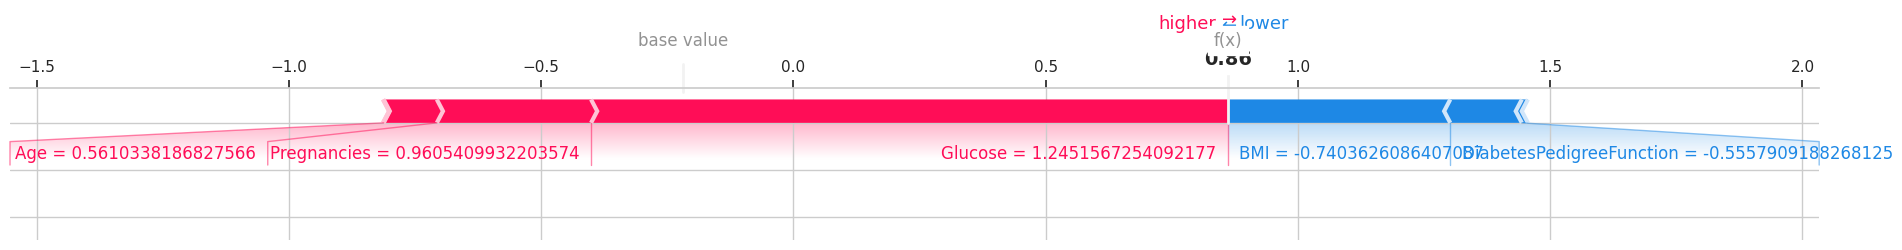

In [40]:
# Explicación de un caso individual: elegimos una paciente concreta del test
# y vemos qué variables la empujaron hacia el diagnóstico de diabetes.

indice_paciente = 0

shap.force_plot(
    explicador.expected_value,
    shap_values[indice_paciente],
    X_test_transformado[indice_paciente],
    feature_names=nombres_variables,
    matplotlib=True, show=False
)
plt.tight_layout()
plt.savefig("fig16_shap_paciente_individual.png", dpi=300, bbox_inches="tight")
plt.show()

En esta paciente concreta, la glucosa alta, los embarazos y la edad empujan con fuerza hacia el diagnóstico de diabetes (la zona roja), mientras que su IMC y el antecedente familiar tiran en sentido contrario (la zona azul). El modelo ofrece un veredicto transparente, ya que muestra el "tira y afloja" entre las variables que lo llevó a esa predicción concreta, y esto es justo lo que necesita un médico para decidir si se fía o si pide una prueba adicional.

# ***Conclusiones***

El trabajo arrancó con la carga del dataset de Pima, un conjunto pequeño y con un problema que condicionó buena parte de las decisiones posteriores: varias variables tenían ceros que en realidad eran datos ausentes. En el bloque 1 nos ocupamos de entender las distribuciones y de montar un preprocesamiento honesto, con imputación diferenciada según el tipo de variable y todo encapsulado en un pipeline que se ajusta solo con el train. Esa base, aunque menos vistosa que el modelado, es la que sostiene que los resultados de después sean creíbles y no fruto de una fuga de datos.

En el bloque 2, comparamos cinco algoritmos en igualdad de condiciones mediante validación cruzada estratificada, y dos destacaron por encima del resto, la Regresión Logística y el SVM. Los afinamos con GridSearchCV y llegaron a la evaluación final muy parejos, con un AUC prácticamente idéntico sobre el test. Hasta ahí ninguno de los dos ganaba de forma clara, así que la decisión no podía basarse solo en la métrica global.

El punto de inflexión estuvo en llevar el problema al terreno clínico. Como un falso negativo aquí es mucho más grave que un falso positivo, ajustamos el umbral de decisión buscando un recall del 85%, y lo calculamos sobre el train para no contaminar el test. Ahí la Regresión Logística sacó ventaja, alcanzaba ese mismo recall con un umbral más alto y arrastrando menos falsos positivos, lo que indica que separaba mejor a las pacientes. Ese fue el argumento clave que hizo inclinar la balanza a su favor.

La interpretabilidad terminó de confirmar la elección. Tanto los coeficientes como la importancia por permutación y el análisis SHAP coincidieron en señalar la glucosa y el IMC como los factores de más peso, justo lo que cabía esperar desde el punto de vista médico. Que el modelo elegido sea además el más transparente, y que apoye su decisión en variables clínicamente coherentes, es lo que lo hace defendible para un entorno hospitalario real y no solo un buen resultado sobre el papel.